# 00 — Dump event study: что происходит ПОСЛЕ дампа?

**Гипотеза (вопрос пользователя):** стоит ли вставать в шорт *в сторону дампа*
(continuation) когда цена за последние 15 минут упала на 1 / 5 / 7%?

Это зеркальный, но другой вопрос относительно pump-ресёча: там мы шортили
*против* движения (fade). Здесь — идём *по* движению вниз.

**Метод (честный, без lookahead):**
- Триггер: `close[t]/close[t-15] - 1 <= -X%`, X ∈ {1, 5, 7}. Считается на
  закрытии бара по прошлым 15 барам.
- **Дедуп по ПЕРВОМУ триггеру кластера** (не по «лучшей минуте» — урок pump).
- Пулинг по многим символам; период **только 2024** (2025/26 = OOS на потом).
- **Baseline** = средний форвардный путь из случайной минуты.
- Метрики на горизонтах 5/15/30/60/240 мин: mean, median, win%, std, q10, mean/std.

In [1]:
import sys; sys.path.insert(0, ".")
from _lab import *
import numpy as np, pandas as pd

# --- universe: symbols with FULL 2024 coverage (all 12 months) -------------
all_syms = list_symbols()
def has_full_2024(s):
    months = {p.stem for p in (loader.DATA_ROOT / s).glob("*.parquet")}
    return all(f"2024-{m:02d}" in months for m in range(1, 13))
UNIV = [s for s in all_syms if has_full_2024(s)]
print(f"universe (full-2024 coverage): {len(UNIV)} symbols")
print(UNIV[:15], "...")

universe (full-2024 coverage): 165 symbols
['10000SATSUSDT', '1000BONKUSDT', '1000BTTUSDT', '1000FLOKIUSDT', '1000LUNCUSDT', '1000PEPEUSDT', '1000RATSUSDT', '1000XECUSDT', 'API3USDT', 'ARKUSDT', 'ARPAUSDT', 'ARUSDT', 'ASTRUSDT', 'ATOMUSDT', 'AUCTIONUSDT'] ...


In [2]:
# Load 2024 1m closes once per symbol; cache to _out/closes_2024.npz
from pathlib import Path
OUT = Path("_out"); OUT.mkdir(exist_ok=True)
cache = OUT / "closes_2024.npz"

# To keep the FIRST pass fast, take a fixed slice of the universe (expand later).
N_SYMS = 50
SYMS = UNIV[:N_SYMS]

closes = {}
if cache.exists():
    z = np.load(cache, allow_pickle=True)
    closes = {k: z[k] for k in z.files}
    print(f"loaded {len(closes)} cached series")
need = [s for s in SYMS if s not in closes]
if need:
    for i, s in enumerate(need):
        try:
            df = ohlcv(s, "2024-01-01", "2025-01-01", "1min")
            closes[s] = df["close"].to_numpy(dtype="float64")
        except Exception as e:
            print("skip", s, e)
        if (i+1) % 10 == 0: print(f"  loaded {i+1}/{len(need)}")
    np.savez_compressed(cache, **{k: closes[k] for k in closes})
    print(f"cached {len(closes)} series -> {cache}")
SYMS = [s for s in SYMS if s in closes]
print(f"using {len(SYMS)} symbols")

  loaded 10/50


  loaded 20/50


  loaded 30/50


  loaded 40/50


  loaded 50/50


cached 50 series -> _out\closes_2024.npz
using 50 symbols


In [3]:
# --- event detection + forward-path collection -----------------------------
WIN = 15                      # trailing window (minutes) for the trigger
THRESH = [0.01, 0.05, 0.07]   # dump magnitudes (positive numbers = -X%)
HZ = [5, 15, 30, 60, 120, 240]  # forward horizons (minutes)
MAXH = max(HZ)

def first_triggers(c, thr):
    # Indices of FIRST minute of each dump cluster (cond goes False->True).
    if len(c) < WIN + MAXH + 2: return np.array([], dtype=int)
    ret15 = np.full(len(c), np.nan)
    ret15[WIN:] = c[WIN:] / c[:-WIN] - 1.0
    cond = ret15 <= -thr
    # first trigger = cond True now AND False on previous minute
    fire = cond.copy()
    fire[1:] &= ~cond[:-1]
    idx = np.where(fire)[0]
    # keep only events with full forward window available
    idx = idx[(idx >= WIN) & (idx + MAXH < len(c))]
    return idx

# collect forward returns relative to trigger-close[i] and to next-bar[i+1]
def collect(thr):
    rows_t0, rows_t1 = [], []   # entry at close[i] / at close[i+1]
    for s in SYMS:
        c = closes[s]
        for i in first_triggers(c, thr):
            base0 = c[i]; base1 = c[i+1]
            rows_t0.append([c[i+h]/base0 - 1 for h in HZ])
            rows_t1.append([c[i+h]/base1 - 1 for h in HZ])
    return np.array(rows_t0), np.array(rows_t1)

events = {thr: collect(thr) for thr in THRESH}
for thr in THRESH:
    print(f"-{int(thr*100)}%/15m : n_events = {len(events[thr][0])}")

-1%/15m : n_events = 260551
-5%/15m : n_events = 2517
-7%/15m : n_events = 1182


In [4]:
# --- baseline: forward returns from RANDOM minutes (unconditional drift) ----
rng = np.random.default_rng(0)
base_rows = []
per_sym = 300
for s in SYMS:
    c = closes[s]
    lo, hi = WIN, len(c) - MAXH - 1
    if hi <= lo: continue
    picks = rng.integers(lo, hi, size=min(per_sym, hi-lo))
    for i in picks:
        base_rows.append([c[i+h]/c[i] - 1 for h in HZ])
BASE = np.array(base_rows)
print("baseline n =", len(BASE))

baseline n = 15000


[saved] notebooks\dump\_out\00_dump_paths.png


WindowsPath('C:/projects/researchlab/notebooks/dump/_out/00_dump_paths.png')

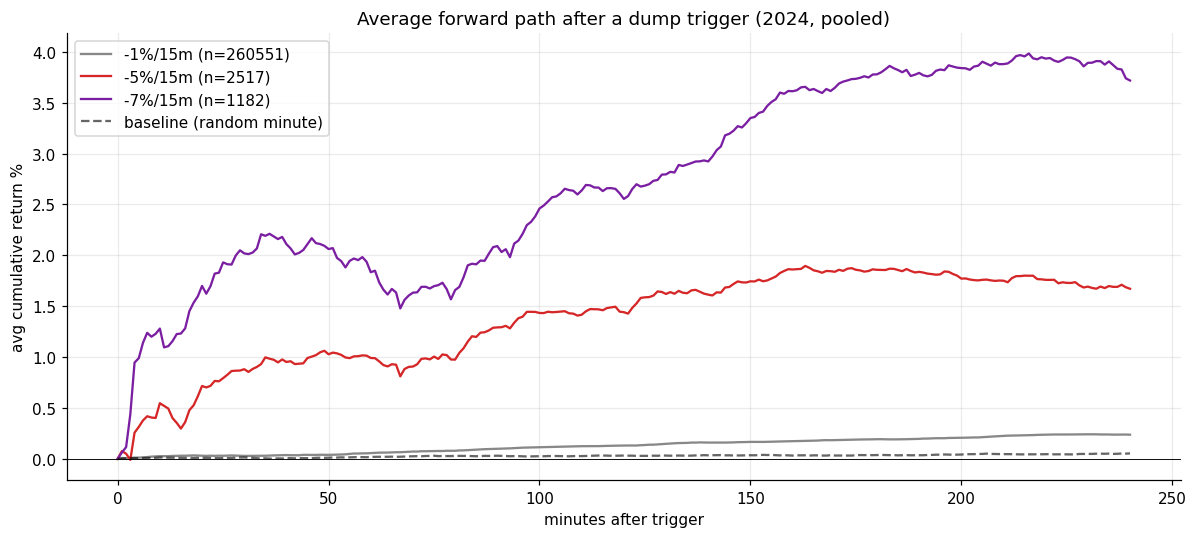

In [5]:
# --- average forward PRICE PATH (dense grid) to SEE shape ------------------
PATH_H = np.arange(0, MAXH+1, 1)
def avg_path(thr):
    acc = np.zeros(len(PATH_H)); n = 0
    for s in SYMS:
        c = closes[s]
        for i in first_triggers(c, thr):
            acc += c[i:i+len(PATH_H)]/c[i] - 1
            n += 1
    return acc / max(n,1), n

paths = {thr: avg_path(thr) for thr in THRESH}

# baseline path
acc = np.zeros(len(PATH_H)); n=0
for s in SYMS:
    c = closes[s]
    lo, hi = WIN, len(c)-len(PATH_H)-1
    if hi<=lo: continue
    for i in rng.integers(lo, hi, size=min(300, hi-lo)):
        acc += c[i:i+len(PATH_H)]/c[i]-1; n+=1
base_path = acc/max(n,1)

plt.figure(figsize=(11,5))
colors = {0.01:"#888", 0.05:"#d62728", 0.07:"#7b1fa2"}
for thr in THRESH:
    p,n = paths[thr]
    plt.plot(PATH_H, p*100, color=colors[thr], label=f"-{int(thr*100)}%/15m (n={n})")
plt.plot(PATH_H, base_path*100, "k--", alpha=.6, label="baseline (random minute)")
plt.axhline(0, color="k", lw=.6)
plt.xlabel("minutes after trigger"); plt.ylabel("avg cumulative return %")
plt.title("Average forward path after a dump trigger (2024, pooled)")
plt.legend()
show("00_dump_paths")

In [6]:
# --- PnL tables: SHORT continuation. short profit = -(forward return) ------
def stats(arr_col):
    a = arr_col
    return dict(n=len(a), mean=a.mean(), median=np.median(a),
                win=(a>0).mean(), std=a.std(), q10=np.quantile(a,0.10),
                ms=a.mean()/a.std() if a.std()>0 else np.nan)

def table(entry_idx):  # entry_idx: 0 = close[i], 1 = close[i+1]
    out = {}
    for thr in THRESH:
        arr = events[thr][entry_idx]
        d = {}
        for j,h in enumerate(HZ):
            short = -arr[:,j]    # short PnL
            s = stats(short)
            d[f"{h}m"] = s
        out[thr] = d
    return out

def show_table(tbl, title):
    print(f"\n=== {title} : SHORT PnL (mean% | med% | win% | q10% | mean/std) ===")
    for thr in THRESH:
        print(f"\n  -{int(thr*100)}%/15m  (n={tbl[thr]['5m']['n']})")
        for h in HZ:
            s = tbl[thr][f"{h}m"]
            print(f"    {h:>4}m  mean {s['mean']*100:+6.2f}  med {s['median']*100:+6.2f}"
                  f"  win {s['win']*100:4.1f}%  q10 {s['q10']*100:+6.2f}  m/std {s['ms']:+.3f}")

# baseline short PnL for reference (should be ~0)
def base_short_stats():
    print("\n=== BASELINE short PnL (random minute) ===")
    for j,h in enumerate(HZ):
        s = stats(-BASE[:,j])
        print(f"    {h:>4}m  mean {s['mean']*100:+6.2f}  med {s['median']*100:+6.2f}"
              f"  win {s['win']*100:4.1f}%  m/std {s['ms']:+.3f}")

show_table(table(0), "ENTRY @ trigger-bar close (OPTIMISTIC / near-lookahead)")
show_table(table(1), "ENTRY @ next bar (HONEST, +1 bar delay)")
base_short_stats()


=== ENTRY @ trigger-bar close (OPTIMISTIC / near-lookahead) : SHORT PnL (mean% | med% | win% | q10% | mean/std) ===

  -1%/15m  (n=260551)
       5m  mean  -0.01  med  -0.03  win 46.7%  q10  -0.65  m/std -0.019
      15m  mean  -0.03  med  -0.07  win 46.0%  q10  -1.09  m/std -0.029
      30m  mean  -0.03  med  -0.08  win 46.3%  q10  -1.47  m/std -0.020
      60m  mean  -0.06  med  -0.12  win 46.3%  q10  -2.03  m/std -0.028
     120m  mean  -0.13  med  -0.15  win 46.6%  q10  -2.84  m/std -0.048
     240m  mean  -0.24  med  -0.20  win 46.7%  q10  -4.00  m/std -0.064

  -5%/15m  (n=2517)
       5m  mean  -0.31  med  -0.65  win 35.2%  q10  -3.32  m/std -0.106
      15m  mean  -0.30  med  -0.94  win 36.6%  q10  -4.28  m/std -0.074
      30m  mean  -0.88  med  -1.36  win 35.1%  q10  -5.26  m/std -0.218
      60m  mean  -0.99  med  -0.91  win 38.2%  q10  -6.64  m/std -0.217
     120m  mean  -1.44  med  -1.65  win 36.1%  q10  -7.52  m/std -0.273
     240m  mean  -1.67  med  -1.77  win 37.1%  

## Как читать

- **График путей:** ось X — минуты после триггера, ось Y — средняя накопленная
  доходность %. Линия ВНИЗ = дамп продолжается (continuation, шорт зарабатывает).
  Линия ВВЕРХ = отскок (reversion, шорт теряет, лонг зарабатывает). Чёрный
  пунктир — baseline.
- **Таблицы:** PnL ШОРТА. Положительный mean = шорт прибылен. Сравнивай:
  - trigger-close vs next-bar — насколько съедает 1-барная задержка (урок pump);
  - условные числа vs baseline — есть ли вообще edge сверх фона;
  - mean/std (риск-скорректировано), не только mean; q10 = левый хвост.

*Verdict пишем после прогона.*

## VERDICT (iter 00)

**Гипотеза «шортить в сторону дампа» — РЕФУТИРОВАНА.** После дампа цена
отскакивает ВВЕРХ (mean reversion), шорт теряет на всех порогах/горизонтах.
Чем сильнее дамп — тем сильнее отскок: −5%/15m → +1.6%/4h, −7%/15m → +3.8%/4h.
−1%/15m ≈ baseline (мёртвая зона, ниже костов).

**Это зеркало pump-fade — тот же механизм reversion.** Памп откатывает вниз,
дамп отскакивает вверх. Правильная сторона = **LONG отскок**, не шорт.

**Контраст с pump (важно):** edge НЕ front-loaded в бар-триггер. Вход по
close vs next-bar почти идентичны (−7%: −3.72% vs −3.77%) → отскок растянут на
часы → стратегия устойчива к тайму исполнения (в отличие от pump-fade, где
+1 бар убивал edge).

**Дальше:** мерить LONG-сторону честно — распределение, q10 для лонга (хвост =
дампы, что продолжают падать), стоп; затем OOS 2025/26; затем дедуп-якорь
(тут first-trigger, lookahead-free — проверить, не прячется ли отскок до пика
дампа, т.е. не «оракул» ли first-trigger).